## Import Libraries & Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
data = pd.read_csv('Data/dataset-covid19-trade-impact.csv')

# Display First 5 Rows
data.head()

,Direction,Year,Date,Weekday,Country,Commodity,Transport_Mode,Measure,Value,Cumulative
0,Exports,2015,01-01-2015,Thursday,All,All,All,$,104000000,104000000
1,Exports,2015,02-01-2015,Friday,All,All,All,$,96000000,200000000
2,Exports,2015,03-01-2015,Saturday,All,All,All,$,61000000,262000000
3,Exports,2015,04-01-2015,Sunday,All,All,All,$,74000000,336000000
4,Exports,2015,05-01-2015,Monday,All,All,All,$,105000000,442000000


## Dataset Information

In [2]:
print(data.shape)

data.info()

(111438, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111438 entries, 0 to 111437
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Direction       111438 non-null  object
 1   Year            111438 non-null  int64 
 2   Date            111438 non-null  object
 3   Weekday         111438 non-null  object
 4   Country         111438 non-null  object
 5   Commodity       111438 non-null  object
 6   Transport_Mode  111438 non-null  object
 7   Measure         111438 non-null  object
 8   Value           111438 non-null  int64 
 9   Cumulative      111438 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 8.5+ MB


In [3]:
#Missing Values
data.isnull().sum()

Direction         0
Year              0
Date              0
Weekday           0
Country           0
Commodity         0
Transport_Mode    0
Measure           0
Value             0
Cumulative        0
dtype: int64

## Filter Required Years

In [4]:
data_filtered = data[data['Year'].isin([2019, 2020, 2021])]

data_filtered.head()

,Direction,Year,Date,Weekday,Country,Commodity,Transport_Mode,Measure,Value,Cumulative
64047,Exports,2019,01-01-2019,Tuesday,All,All,All,$,113000000,113000000
64048,Exports,2019,02-01-2019,Wednesday,All,All,All,$,51000000,164000000
64049,Exports,2019,03-01-2019,Thursday,All,All,All,$,143000000,306000000
64050,Exports,2019,04-01-2019,Friday,All,All,All,$,92000000,398000000
64051,Exports,2019,05-01-2019,Saturday,All,All,All,$,51000000,450000000


## Overall Trade Trend

In [5]:
grouped_data = (
    data_filtered
    .groupby(['Year','Date'])['Cumulative']
    .mean()
    .reset_index()
)

grouped_data['Date'] = pd.to_datetime(grouped_data['Date'], format='%d-%m-%Y')

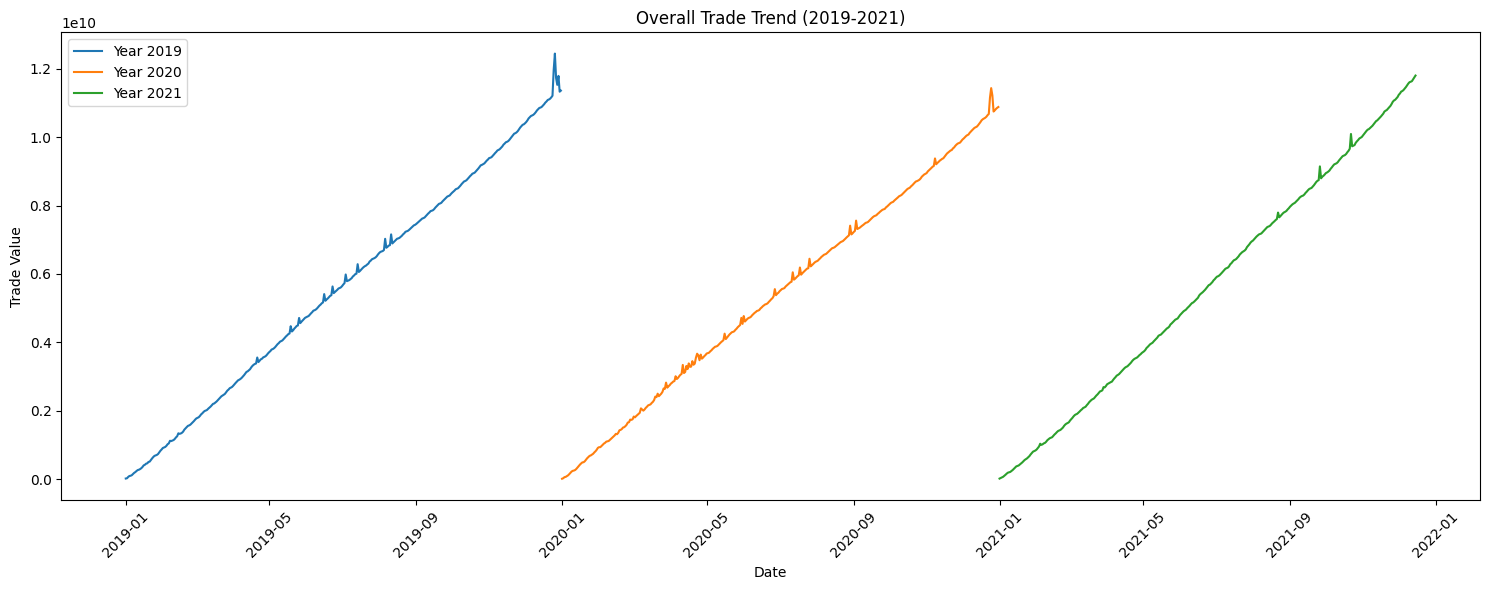

In [6]:
plt.figure(figsize=(15,6))

for year in [2019,2020,2021]:

    yearly_data = (
        grouped_data[grouped_data['Year']==year]
        .sort_values('Date')
    )

    plt.plot(
        yearly_data['Date'],
        yearly_data['Cumulative'],
        label=f'Year {year}'
    )

plt.title("Overall Trade Trend (2019-2021)")
plt.xlabel("Date")
plt.ylabel("Trade Value")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Exports vs Imports

In [7]:
grouped_direction = (
    data_filtered
    .groupby(['Year','Date','Direction'])['Cumulative']
    .mean()
    .reset_index()
)

grouped_direction['Date'] = pd.to_datetime(
    grouped_direction['Date'],
    format='%d-%m-%Y'
)

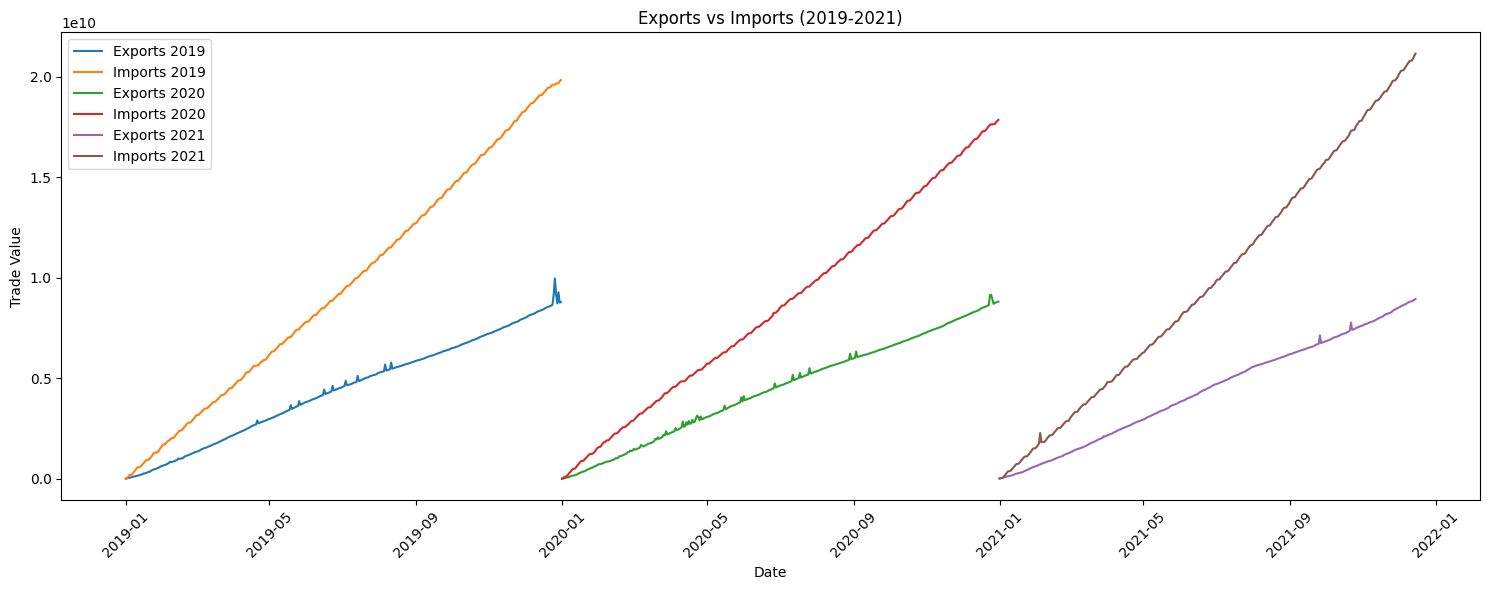

In [8]:
plt.figure(figsize=(15,6))

for year in [2019,2020,2021]:

    for direction in ['Exports','Imports']:

        subset = (
            grouped_direction[
                (grouped_direction['Year']==year) &
                (grouped_direction['Direction']==direction)
            ]
            .sort_values('Date')
        )

        plt.plot(
            subset['Date'],
            subset['Cumulative'],
            label=f'{direction} {year}'
        )

plt.title("Exports vs Imports (2019-2021)")
plt.xlabel("Date")
plt.ylabel("Trade Value")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Commodity Analysis

In [9]:
last_dates = (
    data_filtered
    .groupby('Year')['Date']
    .max()
    .values
)

commodity_data = (
    data_filtered[
        data_filtered['Date'].isin(last_dates)
    ]
    .groupby(['Year','Commodity'])['Cumulative']
    .mean()
    .reset_index()
)

commodity_data['Growth'] = (
    commodity_data
    .groupby('Commodity')['Cumulative']
    .pct_change()
)

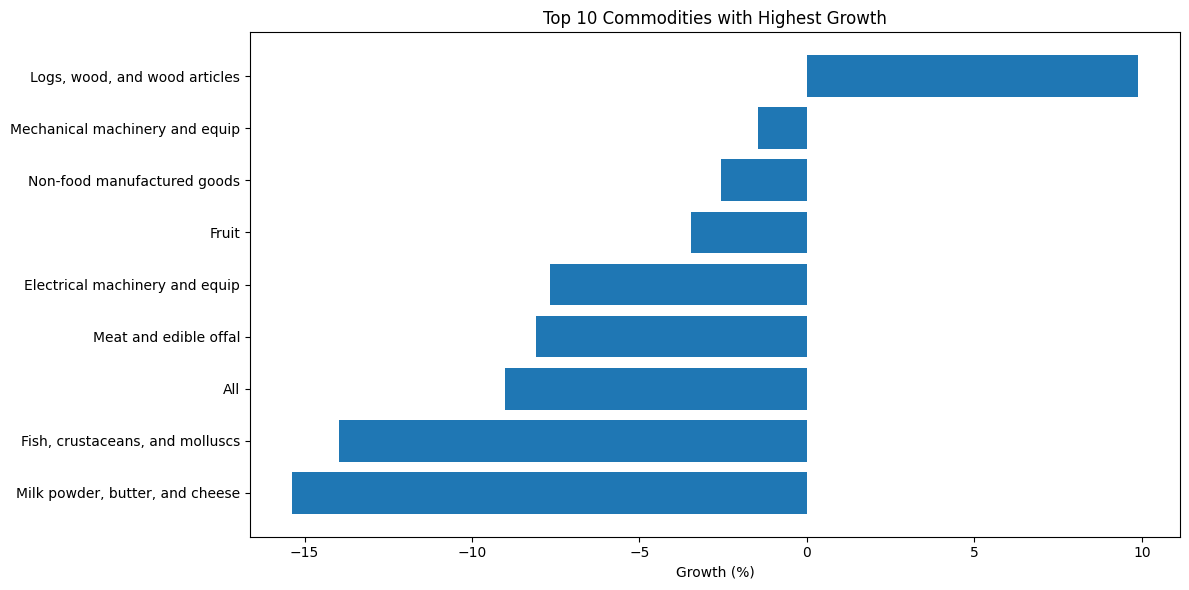

In [10]:
top_commodities = (
    commodity_data[
        commodity_data['Year']==2021
    ]
    .sort_values(
        'Growth',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_commodities['Commodity'],
    top_commodities['Growth']*100
)

plt.title("Top 10 Commodities with Highest Growth")
plt.xlabel("Growth (%)")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Transport Mode Analysis

In [11]:
transport_data = (
    data_filtered[
        data_filtered['Date'].isin(last_dates)
    ]
    .groupby(['Year','Transport_Mode'])['Cumulative']
    .mean()
    .reset_index()
)

transport_data['Growth'] = (
    transport_data
    .groupby('Transport_Mode')['Cumulative']
    .pct_change()
)

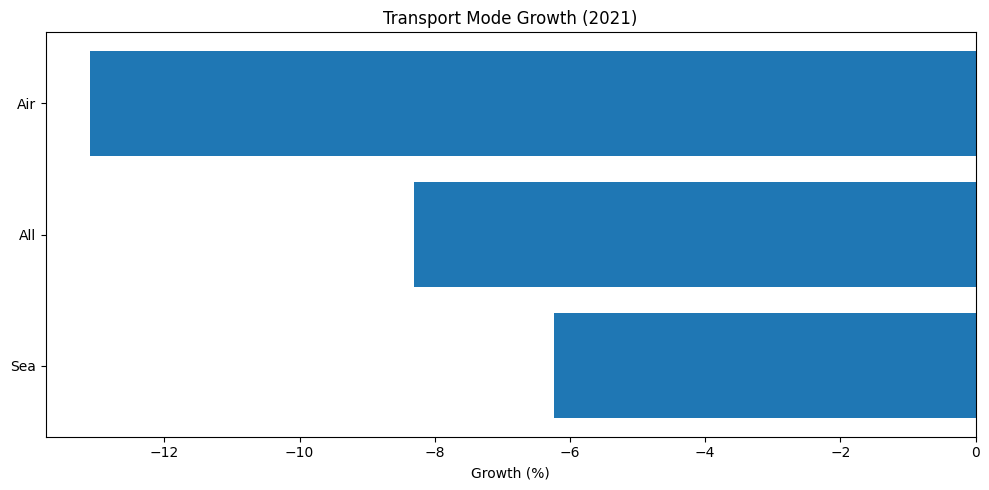

In [12]:
transport_2021 = transport_data[
    transport_data['Year']==2021
]

plt.figure(figsize=(10,5))

plt.barh(
    transport_2021['Transport_Mode'],
    transport_2021['Growth']*100
)

plt.title("Transport Mode Growth (2021)")
plt.xlabel("Growth (%)")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Country Analysis

In [13]:
country_data = (
    data_filtered[
        (data_filtered['Date'].isin(last_dates))
        &
        (data_filtered['Country']!='All')
    ]
    .groupby(['Year','Country'])['Cumulative']
    .mean()
    .reset_index()
)

country_data['Growth'] = (
    country_data
    .groupby('Country')['Cumulative']
    .pct_change()
)

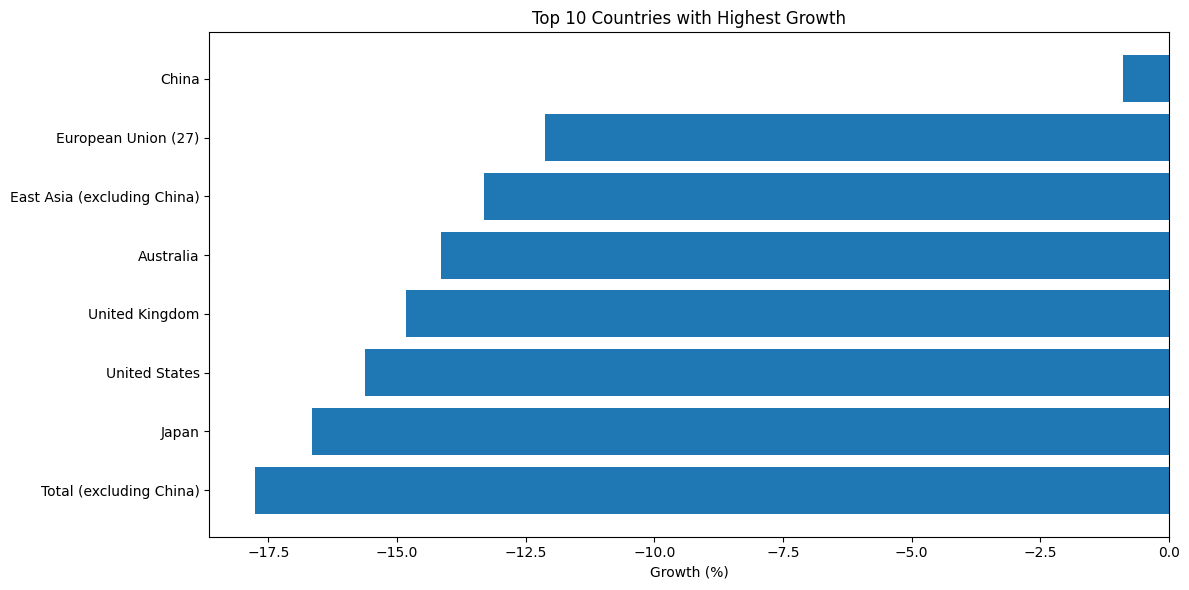

In [14]:
top_countries = (
    country_data[
        country_data['Year']==2021
    ]
    .sort_values(
        'Growth',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_countries['Country'],
    top_countries['Growth']*100
)

plt.title("Top 10 Countries with Highest Growth")
plt.xlabel("Growth (%)")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()